# GAN 1D Probability Distribution Learning

Generative Adversarial Networks (GANs) contain two networks trained concurrently: a Generator that builds fake samples to trick a Discriminator, and a Discriminator that classifies real vs. fake samples. This script constructs a mini GAN in PyTorch to learn a 1D Gaussian probability distribution.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate real data: 1D Gaussian distribution centered at 3.0 with standard deviation 0.5
def sample_real_data(batch_size):
    data = np.random.normal(3.0, 0.5, (batch_size, 1))
    return torch.FloatTensor(data)

# Noise vector coordinates
def sample_noise(batch_size, latent_dim=5):
    return torch.randn(batch_size, latent_dim)



## Generator and Discriminator Neural Networks

We define our networks in PyTorch:
1. **Generator**: Takes a 5-dimensional latent noise vector and outputs a single 1D feature prediction.
2. **Discriminator**: Takes a 1D feature coordinate and predicts a probability classification score (0 = Fake, 1 = Real).



In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

latent_dim = 5
G = Generator(latent_dim)
D = Discriminator()

# Optimizers & Loss function (Binary Cross Entropy)
g_opt = optim.Adam(G.parameters(), lr=0.01)
d_opt = optim.Adam(D.parameters(), lr=0.01)
criterion = nn.BCELoss()



## GAN Adversarial Training Loop

We train both networks for 50 epochs. In each epoch:
1. We update D to correctly classify real samples as 1 and generated samples as 0.
2. We update G to maximize the probability of D classifying generated samples as 1.



In [3]:
batch_size = 64
epochs = 50

for epoch in range(1, epochs + 1):
    # 1. Train Discriminator
    D.zero_grad()
    
    real_data = sample_real_data(batch_size)
    real_labels = torch.ones(batch_size, 1)
    d_real_pred = D(real_data)
    d_real_loss = criterion(d_real_pred, real_labels)
    
    noise = sample_noise(batch_size, latent_dim)
    fake_data = G(noise)
    fake_labels = torch.zeros(batch_size, 1)
    d_fake_pred = D(fake_data.detach())
    d_fake_loss = criterion(d_fake_pred, fake_labels)
    
    d_loss = d_real_loss + d_fake_loss
    d_loss.backward()
    d_opt.step()
    
    # 2. Train Generator
    G.zero_grad()
    
    g_fake_pred = D(fake_data)
    g_loss = criterion(g_fake_pred, real_labels) # generator wants discriminator to output 1
    g_loss.backward()
    g_opt.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")



Epoch 10/50 | D Loss: 0.8919 | G Loss: 0.9109
Epoch 20/50 | D Loss: 0.7287 | G Loss: 0.7977
Epoch 30/50 | D Loss: 1.1336 | G Loss: 0.4931
Epoch 40/50 | D Loss: 1.4612 | G Loss: 0.4679
Epoch 50/50 | D Loss: 1.6407 | G Loss: 0.8887


## Distribution Curve Visualizations

We evaluate the trained generator by feeding it a sample noise batch and comparing its output probability density function (PDF) curve against the ground truth Gaussian distribution.



<cell>:18: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



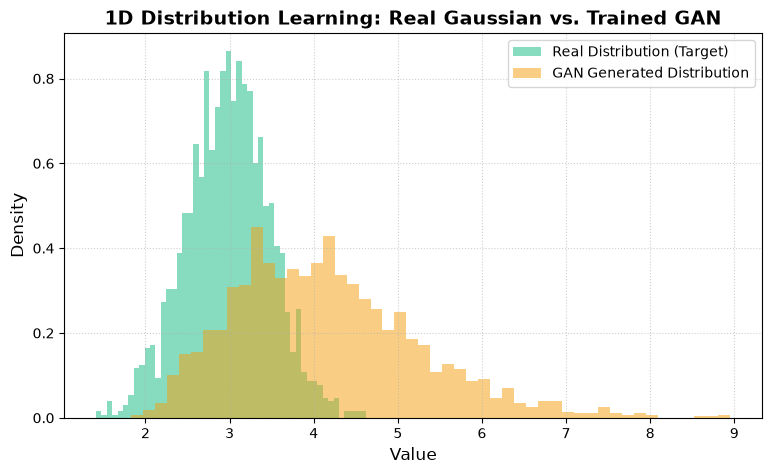

In [4]:
# Evaluate generator outputs
G.eval()
with torch.no_grad():
    eval_noise = sample_noise(2000, latent_dim)
    generated_samples = G(eval_noise).numpy().flatten()

real_samples = sample_real_data(2000).numpy().flatten()

plt.figure(figsize=(9, 5))
plt.hist(real_samples, bins=50, density=True, alpha=0.5, color='#10B981', label='Real Distribution (Target)')
plt.hist(generated_samples, bins=50, density=True, alpha=0.5, color='#F59E0B', label='GAN Generated Distribution')

plt.title('1D Distribution Learning: Real Gaussian vs. Trained GAN', fontsize=14, fontweight='bold')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
